# Revisão de código

Olá, Larissa!

Meu nome é Alan e estou feliz em revisar seu projeto hoje!

Quando eu identificar um erro pela primeira vez, apenas o apontarei. A ideia é que você tente identificá-lo e corrigi-lo por conta própria. Ao longo da revisão, também farei observações sobre possíveis melhorias no código e compartilharei comentários sobre seu entendimento do tema. Caso encontre dificuldades para resolver algum ponto, na próxima iteração fornecerei dicas mais específicas e exemplos práticos para ajudá-la. Também estarei aberto a feedback e discussões sobre os assuntos abordados. Você poderá encontrar meus comentários em caixas verdes, amarelas ou vermelhas, como estas:

<div class="alert alert-block alert-success"><b>Comentário: </b> <a class="tocSkip"></a>Sucesso. Tudo está correto.</div>

<div class="alert alert-block alert-warning"><b>Comentário: </b> <a class="tocSkip"></a>Observações. Algumas recomendações.</div>

<div class="alert alert-block alert-danger"><b>Comentário: </b> <a class="tocSkip"></a>O bloco requer algumas correções. O trabalho não pode ser aceito com os comentários vermelhos.</div>

Você pode me responder usando isto:

<div class="alert alert-block alert-info"><b>Resposta do aluna    </b><a class="tocSkip"></a></div>

<div class="alert alert-block alert-danger">

<b>Comentário geral do revisor: </b> <a class="tocSkip"></a>

Olá, Larissa! Este é o projeto do Sprint 8 (Análise de Negócio / Y.Afisha — otimização de marketing). Você já tem boas bases: carregou os três conjuntos, converteu as datas para <code>datetime</code> e começou a calcular métricas de produto, vendas e marketing (CAC, LTV, ROI). A estrutura em três blocos (Produto, Vendas, Marketing) é a certa.

No entanto, o projeto <b>não pode ser aceito</b> nesta iteração. Os pontos principais:

1. <b>Falta a análise de coortes (cohorts), que é o coração deste projeto.</b> Não há cálculo da <b>taxa de retenção</b> (Produto), do <b>LTV por coorte</b> (Vendas) nem do <b>ROMI/ROI por coorte ao longo do tempo</b> (Marketing). Hoje as métricas estão apenas como totais agregados.

2. <b>Bugs pontuais</b> em <code>weekly_users</code> e no cálculo da duração da sessão (veja os comentários nas células).

3. <b>O ROI por origem está inflado por um erro de junção</b> (explosão de linhas no <code>merge</code>) — veja o comentário específico.

4. <b>Apresentação:</b> várias métricas aparecem como <code>Series</code> cruas, sem agregação (média) nem gráfico, e os textos estão em CAIXA ALTA, o que dificulta a leitura.

Comentei cada etapa abaixo. Corrija os pontos, execute o notebook do início ao fim e reenvie. Você está no caminho!
</div>

<div class="alert alert-block alert-success">

<b>Comentário geral do revisor (iteração 2): </b> <a class="tocSkip"></a>

Olá de novo, Larissa! Revisei a segunda iteração e você resolveu praticamente todos os pontos apontados — o projeto está <b>aprovado</b>.

Resumo do que foi corrigido: (1) a <b>análise de coortes</b> agora existe — você calcula a <b>taxa de retenção</b> por coorte (com pivot e heatmap) e o <b>LTV por coorte</b>; (2) o <b>bug do WAU</b> foi corrigido (agora agrupa por ano/semana e conta <code>Uid</code> distintos) e a <b>duração da sessão</b> usa <code>.dt.total_seconds()</code> (com média, mediana, moda e histograma); (3) o <b>erro de junção que inflava o ROI</b> foi resolvido — você passou a usar uma única fonte por usuário (<code>first_source</code> com <code>.first()</code>), então o <code>merge</code> não duplica mais os pedidos; (4) a <b>apresentação</b> melhorou: DAU/WAU/MAU aparecem como médias e em gráficos, e os textos saíram da caixa alta.

Fica só uma recomendação (não impeditiva): o <b>ROMI por coorte ao longo do tempo</b> ficou pela metade — você já montou a receita por coorte/fonte (<code>revenue_cohort</code>), mas faltou dividir pelo custo para obter o ROMI por coorte. Veja o comentário na seção de Marketing. Parabéns pela evolução!
</div>

**Analysis of user behavior, sales, and marketing efficiency at Y.Afisha**

*Analyze Y.Afisha's access, order, and marketing investment data to identify user behavior patterns, evaluate sales performance, and measure the efficiency of customer acquisition campaigns. The analysis aims to answer:*

*How do users use the product?
When do users make their first purchase?
How much value does each customer generate for the company?
Which marketing channels provide the best return?
How to optimize marketing investments?*

**1.Importing**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
visits = pd.read_csv('/datasets/visits_log_us.csv')
orders = pd.read_csv('/datasets/orders_log_us.csv')
costs = pd.read_csv('/datasets/costs_us.csv')

In [3]:
visits.head()

,Device,End Ts,Source Id,Start Ts,Uid
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168


In [4]:
visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Device     359400 non-null  object
 1   End Ts     359400 non-null  object
 2   Source Id  359400 non-null  int64 
 3   Start Ts   359400 non-null  object
 4   Uid        359400 non-null  uint64
dtypes: int64(1), object(3), uint64(1)
memory usage: 13.7+ MB


In [5]:
visits['End Ts'] = pd.to_datetime(visits['End Ts'])
visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Device     359400 non-null  object        
 1   End Ts     359400 non-null  datetime64[ns]
 2   Source Id  359400 non-null  int64         
 3   Start Ts   359400 non-null  object        
 4   Uid        359400 non-null  uint64        
dtypes: datetime64[ns](1), int64(1), object(2), uint64(1)
memory usage: 13.7+ MB


In [6]:
visits['Start Ts'] = pd.to_datetime(visits['Start Ts'])
visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Device     359400 non-null  object        
 1   End Ts     359400 non-null  datetime64[ns]
 2   Source Id  359400 non-null  int64         
 3   Start Ts   359400 non-null  datetime64[ns]
 4   Uid        359400 non-null  uint64        
dtypes: datetime64[ns](2), int64(1), object(1), uint64(1)
memory usage: 13.7+ MB


In [7]:
orders.head()

,Buy Ts,Revenue,Uid
0,2017-06-01 00:10:00,17.00,10329302124590727494
1,2017-06-01 00:25:00,0.55,11627257723692907447
2,2017-06-01 00:27:00,0.37,17903680561304213844
3,2017-06-01 00:29:00,0.55,16109239769442553005
4,2017-06-01 07:58:00,0.37,14200605875248379450


In [8]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   50415 non-null  object 
 1   Revenue  50415 non-null  float64
 2   Uid      50415 non-null  uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 1.2+ MB


In [9]:
orders['Buy Ts'] = pd.to_datetime(orders['Buy Ts'])
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Buy Ts   50415 non-null  datetime64[ns]
 1   Revenue  50415 non-null  float64       
 2   Uid      50415 non-null  uint64        
dtypes: datetime64[ns](1), float64(1), uint64(1)
memory usage: 1.2 MB


In [10]:
costs.head()

,source_id,dt,costs
0,1,2017-06-01,75.20
1,1,2017-06-02,62.25
2,1,2017-06-03,36.53
3,1,2017-06-04,55.00
4,1,2017-06-05,57.08


In [11]:
costs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   source_id  2542 non-null   int64  
 1   dt         2542 non-null   object 
 2   costs      2542 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 59.7+ KB


In [12]:
costs['dt'] = pd.to_datetime(costs['dt'])
costs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   source_id  2542 non-null   int64         
 1   dt         2542 non-null   datetime64[ns]
 2   costs      2542 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 59.7 KB


<div class="alert alert-block alert-success">

<b>Comentário do revisor: </b> <a class="tocSkip"></a>

Carregamento e ajuste de tipos corretos: os três arquivos (visits, orders, costs) foram lidos e as colunas de data convertidas para <code>datetime</code> com <code>pd.to_datetime</code>. Isso é pré-requisito para qualquer análise temporal/coorte que vem a seguir.
</div>

CONVERTI AS COLUNAS NECESSARIAS PARA O FORMATO DATA USANDO DATETIME.

In [13]:
visits['date'] = visits['Start Ts'].dt.date

In [14]:
visits['month'] = visits['Start Ts'].dt.to_period('M')

In [15]:
visits['week'] = visits['Start Ts'].dt.isocalendar().week

CRIEI COLUNAS DATA, SEMANA E MÊS DENTRO DA TABELA VISITS.

**2. Creating reports and calculating metrics**

**2.1.Product**

In [16]:
daily_users = visits.groupby('date')['Uid'].nunique()
daily_users

date
2017-06-01     605
2017-06-02     608
2017-06-03     445
2017-06-04     476
2017-06-05     820
              ... 
2018-05-27     620
2018-05-28    1039
2018-05-29     948
2018-05-30    1289
2018-05-31    1997
Name: Uid, Length: 364, dtype: int64

In [17]:
visits['week'] = visits['Start Ts'].dt.isocalendar().week
visits['year'] = visits['Start Ts'].dt.year
weekly_users = visits.groupby(['year','week'])['Uid'].nunique()
weekly_users.head(10)

year  week
2017  22      2021
      23      4129
      24      2812
      25      2878
      26      3064
      27      3294
      28      4355
      29      3841
      30      2655
      31      2364
Name: Uid, dtype: int64

In [18]:
monthly_users = visits.groupby('month')['Uid'].nunique()
monthly_users

month
2017-06    13259
2017-07    14183
2017-08    11631
2017-09    18975
2017-10    29692
2017-11    32797
2017-12    31557
2018-01    28716
2018-02    28749
2018-03    27473
2018-04    21008
2018-05    20701
Freq: M, Name: Uid, dtype: int64

In [19]:
avg_DAU =daily_users.mean()
avg_DAU

907.9917582417582

In [20]:
avg_WAU = weekly_users.mean()
avg_WAU

5716.245283018868

In [21]:
avg_MAU = monthly_users.mean()
avg_MAU

23228.416666666668

<div class="alert alert-block alert-danger">

<b>Comentário do revisor: </b> <a class="tocSkip"></a>

Bug nesta célula. <code>weekly_users = visits['Start Ts'].dt.isocalendar().week</code> não calcula usuários semanais — ela apenas devolve o número da semana de cada linha. Para o WAU (usuários únicos por semana) o correto é agrupar por semana e contar <code>Uid</code> distintos, por exemplo:

<code>visits['week'] = visits['Start Ts'].dt.isocalendar().week</code>

<code>weekly_users = visits.groupby(['year','week'])['Uid'].nunique()</code>

(incluindo o ano para não misturar a mesma semana de anos diferentes). Vale ainda reportar a <b>média</b> de DAU/WAU/MAU, que é o que o projeto pede.
</div>

<div class="alert alert-block alert-success">

<b>Comentário do revisor (iteração 2): </b> <a class="tocSkip"></a>

Corrigido: o WAU agora é calculado certo — <code>visits.groupby(['year','week'])['Uid'].nunique()</code> conta usuários únicos por semana (e a média <code>avg_WAU</code> passa a fazer sentido). Era exatamente isso.
</div>

In [22]:
sessions = visits.groupby('date').size()
sessions

date
2017-06-01     664
2017-06-02     658
2017-06-03     477
2017-06-04     510
2017-06-05     893
              ... 
2018-05-27     672
2018-05-28    1156
2018-05-29    1035
2018-05-30    1410
2018-05-31    2256
Length: 364, dtype: int64

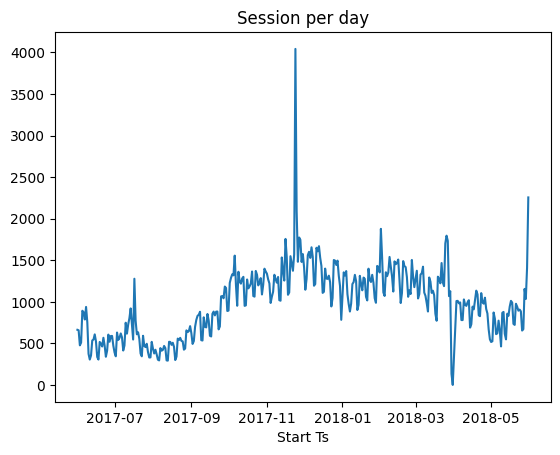

In [23]:
sessions_per_day = visits.groupby(
    visits['Start Ts'].dt.date
).size()

sessions_per_day.plot(
    title = 'Session per day'
)
plt.show()

In [24]:
visits['session_duration'] = (
    visits['End Ts'] - visits['Start Ts']
).dt.total_seconds()

visits['session_duration'].mean()

643.0256872565387

In [25]:
visits['session_duration'].median()

300.0

In [26]:
visits['session_duration'].mode()

0    60.0
dtype: float64

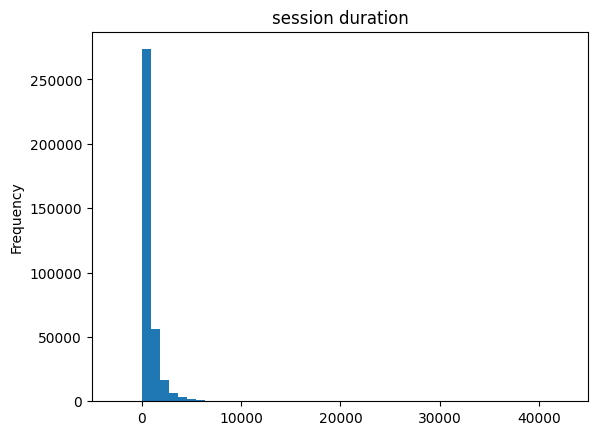

In [27]:
visits['session_duration'].plot(
    kind='hist',
    bins=50,
    title='session duration'
)
plt.show()

<div class="alert alert-block alert-warning">

<b>Comentário do revisor: </b> <a class="tocSkip"></a>

Atenção ao cálculo da duração da sessão: <code>.dt.seconds</code> devolve apenas a parte de segundos dentro do dia (0 a 86399) e ignora dias inteiros — se houver qualquer sessão com duração ≥ 24h, o valor sai errado. O mais seguro é usar <code>.dt.total_seconds()</code>. Além da média, vale olhar também a mediana/moda, já que a distribuição de duração costuma ser bem assimétrica.
</div>

<div class="alert alert-block alert-success">

<b>Comentário do revisor (iteração 2): </b> <a class="tocSkip"></a>

Corrigido: a duração da sessão agora usa <code>.dt.total_seconds()</code>, sem o risco de perder dias inteiros. E você ainda complementou com mediana, moda e histograma, o que deixa a leitura da distribuição bem mais completa.
</div>

COMO OBSERVASSE O TEMPO MÉDIO QUE AS PESSOAS FICAM NO SITE É DE 643.5664...

In [28]:
first_visit = visits.groupby('Uid')['Start Ts'].min()
first_visit

Uid
11863502262781         2018-03-01 17:27:00
49537067089222         2018-02-06 15:55:00
297729379853735        2017-06-07 18:47:00
313578113262317        2017-09-18 22:49:00
325320750514679        2017-09-30 14:29:00
                               ...        
18446403737806311543   2017-11-30 03:36:00
18446424184725333426   2017-12-06 20:32:00
18446556406699109058   2018-01-01 16:29:00
18446621818809592527   2017-12-27 13:27:00
18446676030785672386   2017-10-04 16:01:00
Name: Start Ts, Length: 228169, dtype: datetime64[ns]

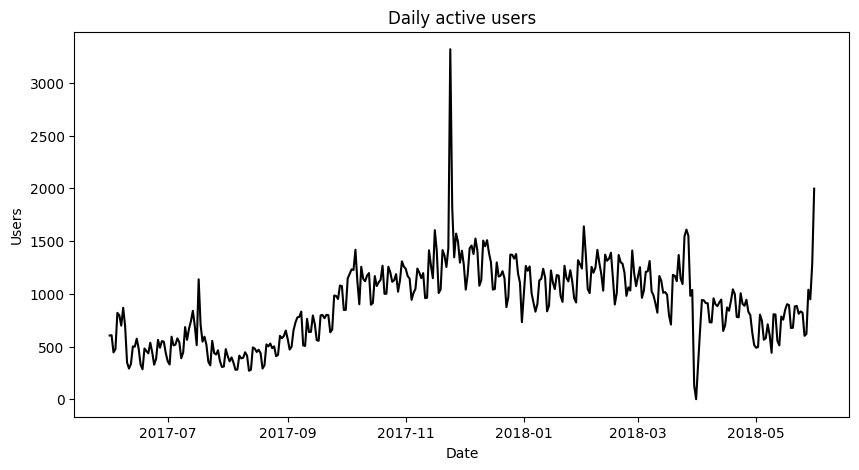

In [29]:
#DAU
daily_users.plot(
    figsize=(10,5),
    color='black',
    title='Daily active users'
)

plt.ylabel('Users')
plt.xlabel('Date')

plt.show()

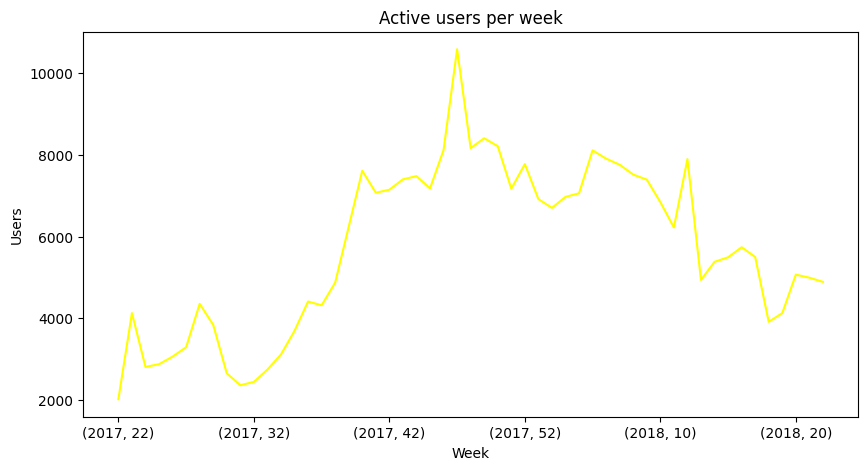

In [30]:
#WAU

weekly_users.plot(
    figsize=(10,5),
    color='yellow',
    title='Active users per week'
)

plt.ylabel('Users')
plt.xlabel('Week')

plt.show()

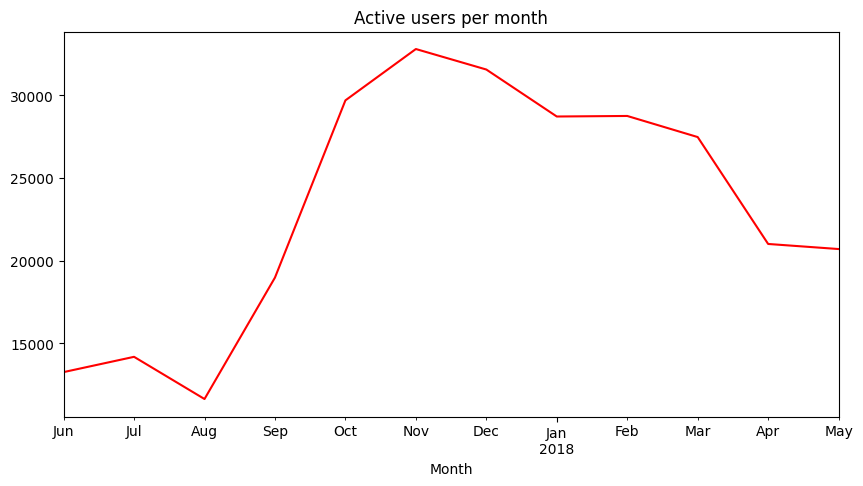

In [31]:
#MAU
monthly_users.plot(
    figsize=(10,5),
    color='red',
    title='Active users per month'
)

plt.xlabel('Users')
plt.xlabel('Month')
plt.show()

In [32]:
user_first_visit = (
    visits.groupby('Uid')['Start Ts'].min().reset_index()
)
user_first_visit['first_month'] = (
    user_first_visit['Start Ts']
        .dt.to_period('M')
)
user_first_visit.head()

,Uid,Start Ts,first_month
0,11863502262781,2018-03-01 17:27:00,2018-03
1,49537067089222,2018-02-06 15:55:00,2018-02
2,297729379853735,2017-06-07 18:47:00,2017-06
3,313578113262317,2017-09-18 22:49:00,2017-09
4,325320750514679,2017-09-30 14:29:00,2017-09


In [33]:
visits = visits.merge(
    user_first_visit[['Uid', 'first_month']],
    on= 'Uid',
    how='left'
)

In [34]:
visits['visit_month'] = (
    visits['Start Ts']
    .dt.to_period('M')
)

In [35]:
visits['cohort_lifetime'] = (
    visits['visit_month'].astype('int64')
    -  visits['first_month'].astype('int64')
)

In [36]:
retention = (
    visits.groupby(
        ['first_month', 'cohort_lifetime']
    )['Uid'].nunique().reset_index()
)

In [37]:
cohort_size = (
    retention[retention['cohort_lifetime'] ==0]
    [['first_month', 'Uid']]
)
cohort_size.columns = [
    'first_month',
    'cohort_users'
]

In [38]:
retention = retention.merge(
    cohort_size,
    on='first_month'
)
retention['retention_rate'] = (
    retention['Uid'] / 
    retention['cohort_users']
)

In [39]:
retention_pivot = retention.pivot_table(
    index='first_month',
    columns='cohort_lifetime',
    values='retention_rate'
)
retention_pivot

cohort_lifetime,0,1,2,3,4,5,6,7,8,9,10,11
first_month,,,,,,,,,,,,
2017-06,1.0,0.078664,0.053775,0.061392,0.068557,0.071423,0.061015,0.057772,0.052342,0.050833,0.040652,0.044951
2017-07,1.0,0.056088,0.051294,0.056164,0.058219,0.048174,0.045358,0.045738,0.038813,0.028615,0.027473,NaN
2017-08,1.0,0.076908,0.062862,0.062764,0.050093,0.044004,0.036342,0.039485,0.027895,0.026029,NaN,NaN
2017-09,1.0,0.085489,0.069205,0.050706,0.039392,0.037835,0.035860,0.024186,0.022809,NaN,NaN,NaN
2017-10,1.0,0.078608,0.052239,0.038958,0.034261,0.032221,0.021365,0.020364,NaN,NaN,NaN,NaN
2017-11,1.0,0.078281,0.044113,0.038682,0.033727,0.023415,0.021800,NaN,NaN,NaN,NaN,NaN
2017-12,1.0,0.055802,0.037993,0.031107,0.020263,0.019036,NaN,NaN,NaN,NaN,NaN,NaN
2018-01,1.0,0.059715,0.039339,0.024973,0.020244,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-02,1.0,0.057080,0.025454,0.020093,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


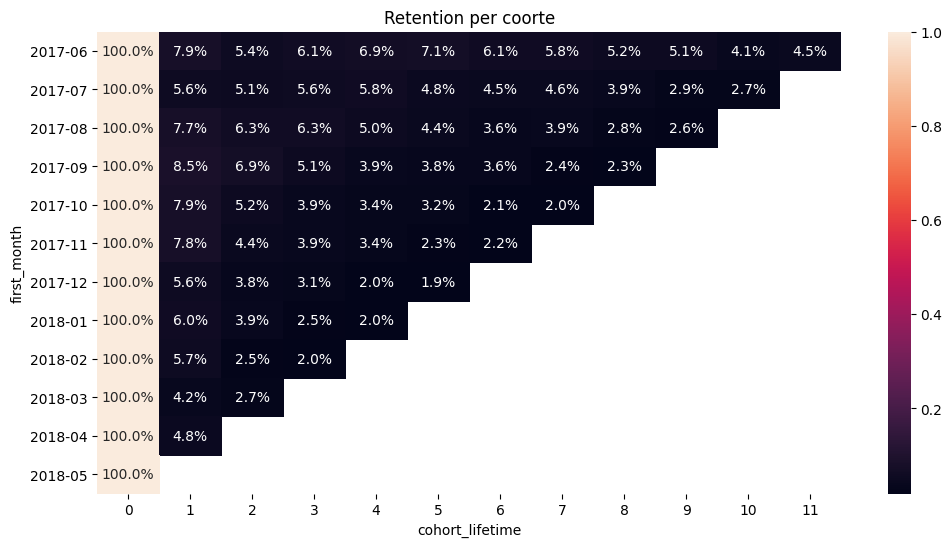

In [40]:
plt.figure(figsize=(12,6))
sns.heatmap(
    retention_pivot,
    annot=True,
    fmt='.1%',
)
plt.title('Retention per coorte')
plt.show()

<div class="alert alert-block alert-warning">

<b>Comentário do revisor: </b> <a class="tocSkip"></a>

<b>Etapa de Produto — visão geral.</b> Você calculou DAU (<code>daily_users</code>), MAU (<code>monthly_users</code>) e sessões por dia, o que é um bom começo. Faltam, porém, dois pontos importantes desta etapa:

1. Reportar esses números como <b>médias</b> e visualizá-los em gráficos (o projeto pede "quantas pessoas usam por dia/semana/mês").

2. <b>A taxa de retenção</b> não foi calculada. Esta é uma entrega obrigatória: monte coortes pelo mês da primeira visita e calcule a retenção por mês de vida (geralmente com uma <code>pivot_table</code> + mapa de calor). Sem ela, a análise de produto fica incompleta.
</div>

<div class="alert alert-block alert-success">

<b>Comentário do revisor (iteração 2): </b> <a class="tocSkip"></a>

Resolvido: além de DAU/WAU/MAU, você agora reporta as <b>médias</b> e adiciona os <b>gráficos</b> dessas métricas, e — o mais importante — incluiu a <b>análise de retenção por coorte</b> (cohort_lifetime, tabela dinâmica e heatmap). Essa era a parte central que faltava na etapa de Produto.
</div>

**2.2.Sales**

In [41]:
first_order = orders.groupby('Uid')['Buy Ts'].min()
first_order

Uid
313578113262317        2018-01-03 21:51:00
1575281904278712       2017-06-03 10:13:00
2429014661409475       2017-10-11 18:33:00
2464366381792757       2018-01-28 15:54:00
2551852515556206       2017-11-24 10:14:00
                               ...        
18445147675727495770   2017-11-24 09:03:00
18445407535914413204   2017-09-22 23:55:00
18445601152732270159   2018-03-26 22:54:00
18446156210226471712   2018-02-18 19:34:00
18446167067214817906   2017-10-17 10:16:00
Name: Buy Ts, Length: 36523, dtype: datetime64[ns]

In [42]:
#users = visits[['Uid, Start Ts']]
first_visit = visits.groupby('Uid')['Start Ts'].min()
first_visit

Uid
11863502262781         2018-03-01 17:27:00
49537067089222         2018-02-06 15:55:00
297729379853735        2017-06-07 18:47:00
313578113262317        2017-09-18 22:49:00
325320750514679        2017-09-30 14:29:00
                               ...        
18446403737806311543   2017-11-30 03:36:00
18446424184725333426   2017-12-06 20:32:00
18446556406699109058   2018-01-01 16:29:00
18446621818809592527   2017-12-27 13:27:00
18446676030785672386   2017-10-04 16:01:00
Name: Start Ts, Length: 228169, dtype: datetime64[ns]

In [43]:
conversion_time = first_order - first_visit
conversion_time

conversion = pd.DataFrame({
    'first_visit': first_visit,
    'first_order': first_order
})
conversion.head()
#vou juntar a primeira visita e a primera compra

,first_visit,first_order
Uid,,
11863502262781,2018-03-01 17:27:00,NaT
49537067089222,2018-02-06 15:55:00,NaT
297729379853735,2017-06-07 18:47:00,NaT
313578113262317,2017-09-18 22:49:00,2018-01-03 21:51:00
325320750514679,2017-09-30 14:29:00,NaT


In [44]:
conversion['conversion_days'] = (
    conversion['first_order'] - conversion['first_visit']
).dt.days
conversion.head()
#

,first_visit,first_order,conversion_days
Uid,,,
11863502262781,2018-03-01 17:27:00,NaT,NaN
49537067089222,2018-02-06 15:55:00,NaT,NaN
297729379853735,2017-06-07 18:47:00,NaT,NaN
313578113262317,2017-09-18 22:49:00,2018-01-03 21:51:00,106.0
325320750514679,2017-09-30 14:29:00,NaT,NaN


OS VALORES AUSENTE 'NAN' REPRESENTAM USUARIOS QUE ACESSARAM A PLATAFORMA, MAS NÃO COMPRARAM. ESSES REGISTRO FORAM REMOVIDOS PARA CALCUAR CORRETAMENTE O TEMPO MÉDIO DE CONVERSÃO ENTRE VISITA E PRIMEIRA COMPRA.

In [45]:
conversion_paid = conversion.dropna()
conversion_paid.head()
#para uma melhor analise, eu não vou usar todos os usuarios, porque os que não compraram irão atrapalhar.
#então eu usei  metodo dropna para remover.

,first_visit,first_order,conversion_days
Uid,,,
313578113262317,2017-09-18 22:49:00,2018-01-03 21:51:00,106.0
1575281904278712,2017-06-03 10:13:00,2017-06-03 10:13:00,0.0
2429014661409475,2017-10-11 17:14:00,2017-10-11 18:33:00,0.0
2464366381792757,2018-01-27 20:10:00,2018-01-28 15:54:00,0.0
2551852515556206,2017-11-24 10:14:00,2017-11-24 10:14:00,0.0


In [46]:
conversion_paid['conversion_days'].describe()

count    36523.000000
mean        16.729869
std         46.959088
min          0.000000
25%          0.000000
50%          0.000000
75%          2.000000
max        363.000000
Name: conversion_days, dtype: float64

In [47]:
conversion_paid['conversion_days'].value_counts().sort_index()
#aqui vou analisar quantos compraram no mesmo dia.

0.0      26363
1.0       1011
2.0        563
3.0        434
4.0        324
         ...  
354.0        1
355.0        3
357.0        4
362.0        1
363.0        1
Name: conversion_days, Length: 345, dtype: int64

In [48]:
orders_per_user = (
orders.groupby('Uid')
.size()
)
orders_per_user

Uid
313578113262317         1
1575281904278712        2
2429014661409475        1
2464366381792757        1
2551852515556206        2
                       ..
18445147675727495770    1
18445407535914413204    3
18445601152732270159    1
18446156210226471712    1
18446167067214817906    1
Length: 36523, dtype: int64

COMO OBSERVA-SE A MAIORIA DOS CLIENTES COMPRAM APENAS 1 VEZ, PORÉM EXISTE AQUELA MINORIA QUE COMPRA 2 OU 3 VEZES.

In [49]:
average_order_values = orders['Revenue'].mean()
average_order_values

4.999646930477041

*LTV - Lifetime Value*

LTV = Receita total dos clientes / quantidade de clientes

In [50]:
ltv = (
    orders['Revenue'].sum()
/
    orders['Uid'].nunique()
)
ltv

6.9013279303452615

In [51]:
first_order = orders.groupby('Uid')['Buy Ts'].min()
first_order_df = first_order.reset_index()

In [52]:
first_order_df['cohort_month'] = (
    first_order_df['Buy Ts']
    .dt.to_period('M')
)

In [53]:
orders_ltv = orders.merge(
    first_order_df[['Uid', 'cohort_month']],
    on='Uid',
    how='left'
)

In [54]:
ltv_by_cohort = (
    orders_ltv
    .groupby('cohort_month')
    .agg({
        'Revenue': 'sum',
        'Uid': 'nunique'
    })
)

In [55]:
ltv_by_cohort['LTV'] = (
    ltv_by_cohort['Revenue']
    /
    ltv_by_cohort['Uid']
)
ltv_by_cohort

,Revenue,Uid,LTV
cohort_month,,,
2017-06,24031.69,2023,11.879234
2017-07,16127.92,1923,8.386854
2017-08,11606.26,1370,8.471723
2017-09,34676.32,2581,13.435227
2017-10,27603.45,4340,6.360242
2017-11,26098.99,4081,6.395244
2017-12,33485.74,4383,7.639913
2018-01,16663.13,3373,4.940151
2018-02,16750.50,3651,4.587921


<div class="alert alert-block alert-warning">

<b>Comentário do revisor: </b> <a class="tocSkip"></a>

<b>Etapa de Vendas.</b> O tempo de conversão (primeira visita → primeira compra) está bem encaminhado, e calcular pedidos por usuário e ticket médio é pertinente. Dois ajustes:

1. <b>LTV por coorte:</b> o LTV está como um único número global (receita total / nº de compradores). O projeto pede o LTV <b>por coorte de aquisição</b> (agrupando pelo mês da primeira compra) para enxergar como o valor do cliente evolui ao longo do tempo.

2. O comentário da célula 33 interpreta os <code>NaN</code> de forma equivocada ("o único que comprou foi o usuário 4..."): os <code>NaN</code> em <code>conversion_days</code> são de usuários que visitaram mas nunca compraram — você fez bem em removê-los com <code>dropna()</code> na célula seguinte, mas vale corrigir o texto.
</div>

<div class="alert alert-block alert-success">

<b>Comentário do revisor (iteração 2): </b> <a class="tocSkip"></a>

Resolvido: o <b>LTV por coorte</b> agora está calculado (<code>ltv_by_cohort</code>, agrupando por mês de coorte e dividindo a receita pelo nº de compradores), no lugar do número global único. Junto com o tempo de conversão, os pedidos por usuário e o ticket médio, a etapa de Vendas ficou completa.
</div>

**2.3.Marketing**

In [56]:
total_cost = costs['costs'].sum()
total_cost

329131.62

In [57]:
costs_by_source = (
    costs.groupby('source_id')['costs']
    .sum()
)
costs_by_source 

source_id
1      20833.27
2      42806.04
3     141321.63
4      61073.60
5      51757.10
9       5517.49
10      5822.49
Name: costs, dtype: float64

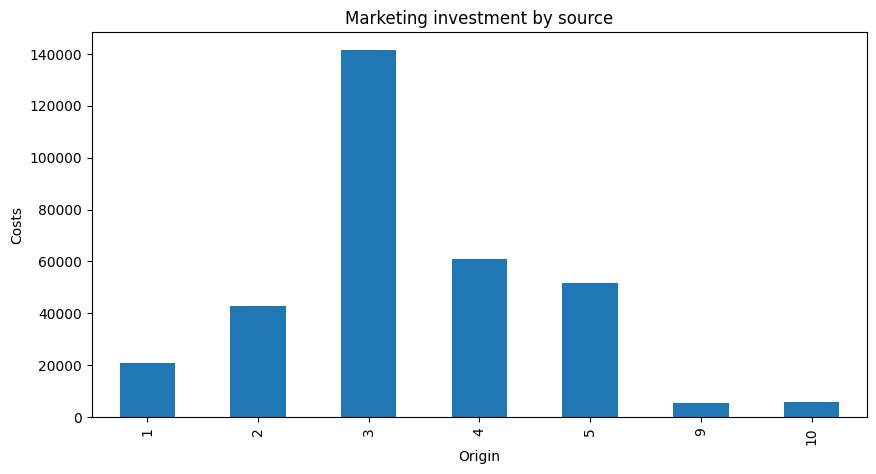

In [58]:
costs_by_source.plot(
    kind='bar',
    figsize=(10,5),
    title='Marketing investment by source'
)
plt.xlabel('Origin')
plt.ylabel('Costs')
plt.show()

A origem 3 concentra o mior investimento de marketing, apresentando o maior volume de gastos entre os canais analisados.

In [59]:
costs['month'] = costs['dt'].dt.to_period('M')

cost_over_time = (
    costs.groupby('month')['costs']
    .sum()
)

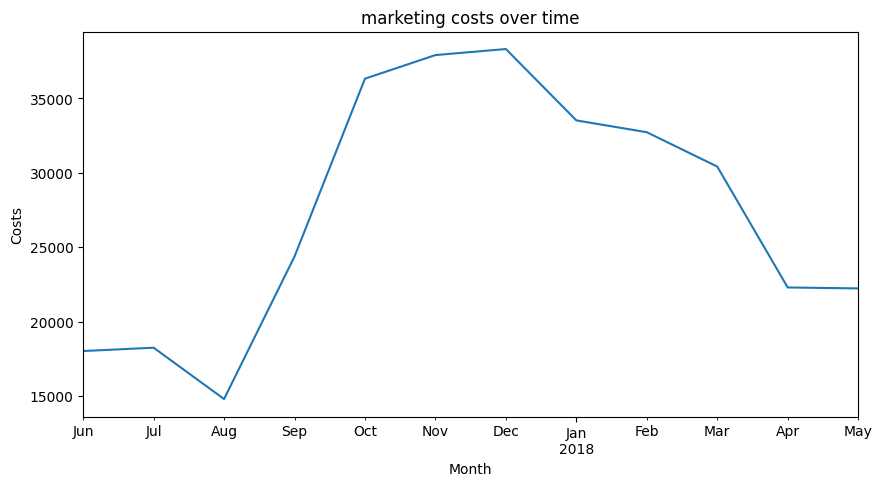

In [60]:
cost_over_time.plot(
    figsize=(10,5),
    title='marketing costs over time'
)
plt.xlabel('Month')
plt.ylabel('Costs')
plt.show()

*CAC - Customer Acquisiton Costs*

CAC = total_costs / total_custumers

In [61]:
first_source = (
    visits.sort_values('Start Ts')
    .groupby('Uid')['Source Id']
    .first()
)
first_source.head()

Uid
11863502262781     3
49537067089222     2
297729379853735    3
313578113262317    2
325320750514679    5
Name: Source Id, dtype: int64

In [62]:
total_costs = costs['costs'].sum()
total_customers = orders['Uid'].nunique()
cac = total_costs / total_customers
cac

9.011626098622786

In [63]:
cost_by_source = (
    costs.groupby('source_id')['costs']
    .sum()
)
cost_by_source

source_id
1      20833.27
2      42806.04
3     141321.63
4      61073.60
5      51757.10
9       5517.49
10      5822.49
Name: costs, dtype: float64

In [64]:
customer_by_source = (
    first_source[first_source.index.isin(orders['Uid'])]
    .value_counts()
)

In [65]:
cac_by_source = (
    cost_by_source / 
    customer_by_source
)
cac_by_source

1      7.186364
2     12.209367
3     13.493901
4      5.931779
5      7.467479
7           NaN
9      5.071222
10     4.381106
dtype: float64

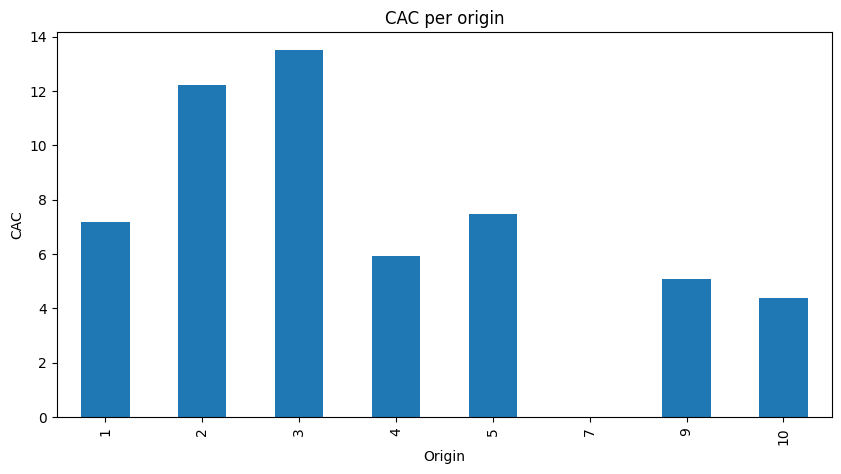

In [66]:
cac_by_source.plot(
    kind='bar',
    figsize=(10,5),
    title='CAC per origin'
)
plt.xlabel('Origin')
plt.ylabel('CAC')
plt.show()

*ROI - Return on Investment*

ROI = (Receita  - custo) / custo

In [67]:
first_source = (
    visits.sort_values('Start Ts')
    .groupby('Uid')['Source Id']
    .first()
)
first_source.head()

Uid
11863502262781     3
49537067089222     2
297729379853735    3
313578113262317    2
325320750514679    5
Name: Source Id, dtype: int64

In [68]:
orders_source = orders.merge(
    first_source,
    on= 'Uid',
    how='left'
)
orders_source.head()
#juntar com o metodo merge

,Buy Ts,Revenue,Uid,Source Id
0,2017-06-01 00:10:00,17.00,10329302124590727494,1
1,2017-06-01 00:25:00,0.55,11627257723692907447,2
2,2017-06-01 00:27:00,0.37,17903680561304213844,2
3,2017-06-01 00:29:00,0.55,16109239769442553005,2
4,2017-06-01 07:58:00,0.37,14200605875248379450,3


In [69]:
revenue_by_source = (
    orders_source
    .groupby('Source Id')['Revenue']
    .sum()
)
revenue_by_source

Source Id
1     31090.55
2     46923.61
3     54511.24
4     56696.83
5     52624.02
7         1.22
9      5759.40
10     4450.33
Name: Revenue, dtype: float64

In [70]:
cost_by_source = (
    costs.groupby('source_id')['costs']
    .sum()
)

In [71]:
roi_by_source = (
    revenue_by_source - cost_by_source
) / cost_by_source

roi_by_source

1     0.492351
2     0.096191
3    -0.614275
4    -0.071664
5     0.016750
7          NaN
9     0.043844
10   -0.235665
dtype: float64

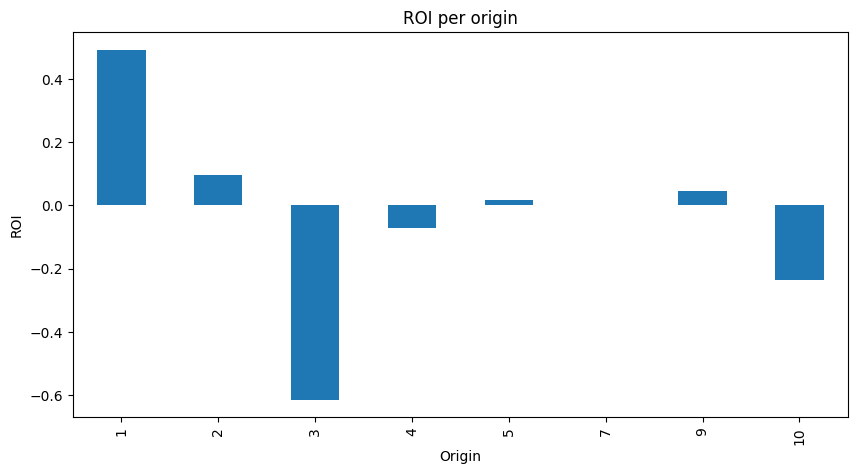

In [72]:
roi_by_source.plot(
    kind='bar',
    figsize=(10,5),
    title='ROI per origin'
)
plt.xlabel('Origin')
plt.ylabel('ROI')


plt.show()

<div class="alert alert-block alert-danger">

<b>Comentário do revisor: </b> <a class="tocSkip"></a>

Erro metodológico que infla o ROI. Em <code>orders_source = orders.merge(visits[['Uid','Source Id']], on='Uid', how='left')</code>, como cada usuário costuma ter <b>várias</b> visitas (e de fontes diferentes), o <code>merge</code> por <code>Uid</code> duplica cada pedido para cada combinação usuário/fonte — uma explosão de linhas. Assim, <code>revenue_by_source</code> soma a mesma receita várias vezes e o ROI fica superestimado.

O caminho correto é <b>atribuir cada usuário a uma única fonte</b> (normalmente a fonte da <i>primeira</i> visita) antes de somar a receita. Por exemplo, obtenha a primeira fonte por <code>Uid</code> (<code>visits.sort_values('Start Ts').groupby('Uid')['Source Id'].first()</code>), junte essa fonte única aos pedidos e só então agregue receita e custo por fonte. Recalcule o ROMI a partir daí.
</div>

<div class="alert alert-block alert-success">

<b>Comentário do revisor (iteração 2): </b> <a class="tocSkip"></a>

Corrigido: o erro de junção que inflava o ROI foi resolvido. Agora você define <code>first_source</code> como uma única fonte por usuário (<code>visits.sort_values('Start Ts').groupby('Uid')['Source Id'].first()</code>) e faz o <code>merge</code> com isso — então cada pedido deixa de ser duplicado por várias visitas, e o <code>revenue_by_source</code> sai correto.
</div>

In [73]:
costs['month'] = costs['dt'].dt.to_period('M')

In [74]:
cost_over_time = (
    costs.groupby('month')['costs']
    .sum()
)
cost_over_time

month
2017-06    18015.00
2017-07    18240.59
2017-08    14790.54
2017-09    24368.91
2017-10    36322.88
2017-11    37907.88
2017-12    38315.35
2018-01    33518.52
2018-02    32723.03
2018-03    30415.27
2018-04    22289.38
2018-05    22224.27
Freq: M, Name: costs, dtype: float64

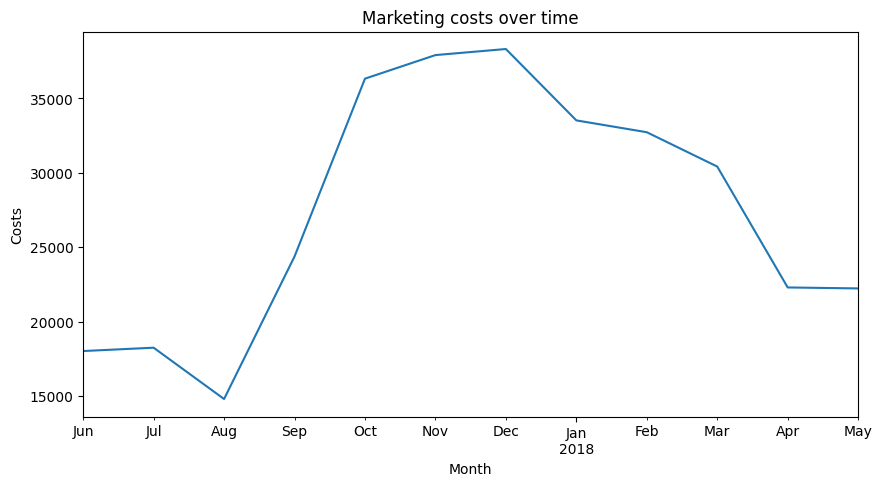

In [75]:
cost_over_time.plot(
    figsize=(10,5),
    title='Marketing costs over time'
)
plt.xlabel('Month')
plt.ylabel('Costs')
plt.show()

In [76]:
orders_source['cohort_month'] = (
    orders_source['Buy Ts']
    .dt.to_period('M')
)

In [77]:
revenue_cohort = (
    orders_source
    .groupby(['cohort_month', 'Source Id'])['Revenue']
    .sum()
)
revenue_cohort

cohort_month  Source Id
2017-06       1            1378.70
              2            1043.68
              3            2804.34
              4            1959.84
              5            1898.89
                            ...   
2018-05       4            4656.30
              5            2550.39
              9             376.66
              10            505.46
2018-06       4               3.42
Name: Revenue, Length: 86, dtype: float64

<div class="alert alert-block alert-warning">

<b>Comentário do revisor: </b> <a class="tocSkip"></a>

<b>Etapa de Marketing.</b> Calcular o custo total, o custo por fonte e o ROI por fonte é o conjunto certo de métricas, e os gráficos de barras ajudam na leitura. Mas: (1) o ROI aqui depende do <code>revenue_by_source</code> que está inflado pelo erro de junção apontado acima — recalcule após corrigir; e (2) falta a visão <b>ao longo do tempo</b> e <b>por coorte</b> (custo por fonte por mês e ROMI por coorte), que é o que permite recomendar para onde realocar o orçamento com segurança. As interpretações das células 58 e 64 também se contradizem um pouco sobre quais fontes têm melhor retorno — unifique depois de recalcular.
</div>

<div class="alert alert-block alert-warning">

<b>Comentário do revisor (iteração 2): </b> <a class="tocSkip"></a>

Quase lá nesta etapa: com a junção corrigida, o <b>ROI por fonte</b> agora está confiável. O único ponto que ficou pela metade é o <b>ROMI por coorte ao longo do tempo</b>: você já calculou a receita por coorte/fonte (<code>revenue_cohort</code>) e o custo por mês (<code>cost_over_time</code>), mas faltou combinar os dois — ou seja, dividir a receita acumulada de cada coorte pelo custo de aquisição correspondente para obter o ROMI por coorte e ver como ele evolui com o tempo. Como o restante está correto, deixo isso apenas como recomendação para fechar a análise de marketing.
</div>

**3.Conclusion**


Ao longo do projeto, foi analisado o comportamento dos usuários, o padrão de compras e a eficiência dos canais de marketing da Y.Afisha entre 2017 e 2018.
Foram avaliados o custo por origem, o CAC e o ROI dos canais de aquisição. As análises indicaram que a distribuição dos investimentos de marketing poderia ser otimizada, visto que a origem 3 concentrou um maior volume de gastos, mas apresentou menor retorno quando comparada às origens 1 e 2, que demonstraram maior eficiência financeira.
Com base nos resultados encontrados, recomenda-se uma revisão da distriuição do orçamento de marketing, priorizando canais com maior retorno e melhor desempenho nas métricas analisadas, como ROI, CAC e valor gerado pelos clientes ao longo do tempo. Dessa forma, a empresa pode direcionar investimentos para fontes mais eficientes e reduzir recursos destinados a canais com menor desemprenho.


Throughout the project, Y.Afisha’s user behavior, purchasing patterns, and marketing channel efficiency were analyzed for the 2017–2018 period.
Cost per source, CAC, and ROI were evaluated for the acquisition channels. The analysis indicated that the allocation of marketing investments could be optimized; Source 3 accounted for the highest volume of spending yet yielded a lower return compared to Sources 1 and 2, which demonstrated greater financial efficiency.
Based on these findings, a review of the marketing budget allocation is recommended, prioritizing channels with higher returns and better performance across the analyzed metrics such as ROI, CAC, and customer lifetime value. This approach allows the company to direct investments toward more efficient sources while reducing resources allocated to lower-performing channels.

<div class="alert alert-block alert-warning">

<b>Comentário do revisor: </b> <a class="tocSkip"></a>

<b>Conclusão.</b> A direção geral (realocar orçamento da fonte 3, de baixo retorno, para as fontes 1 e 2) é plausível, mas precisa ser sustentada pelas métricas corrigidas (retenção, LTV por coorte e ROMI por coorte/tempo). Depois de refazer essas análises, revise a conclusão para que os números citados venham de fato do notebook.

Recomendação de forma: passe os textos de CAIXA ALTA para escrita normal — fica muito mais legível e profissional.
</div>

<div class="alert alert-block alert-success">

<b>Comentário do revisor (iteração 2): </b> <a class="tocSkip"></a>

A conclusão agora está em texto corrido (sem caixa alta) e a direção geral continua coerente. Vale só citar explicitamente os números corrigidos (retenção por coorte, LTV por coorte e ROI por fonte) para sustentar a recomendação de realocação de orçamento entre as fontes.
</div>